<a href="https://colab.research.google.com/github/Lievaashini/Lieva---ML/blob/main/wid3006_assignment_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group Assignment: Tying the (Data) Knot: Love, Life & Likes**
Project Title: Interest-Based Matching: Predicting User Interests via Digital Behavior



---


**Group Members:**

WONG XIANG HONG |

KAMILIA AHLAM TAQI BINTI TAQI MOHAMED | 24001462

SHAHITYA SHRI A/P SRI KRISHNAH | 25006586

LIEVASHINI A/P THANASEGARAN | 25006877

HARSHINI |

TIGITRA |


Objective: To develop a machine learning model that predicts a user's primary interests by analyzing their app interaction patterns (swipe ratios, usage time, and engagement metrics).



---


# Data Loading & Setup

In [5]:
# Data Handling & Math
import pandas as pd  # Used to load and clean 50,000 records
import numpy as np   # Used for high-level mathematical functions

# Data Pre-processing
from sklearn.model_selection import train_test_split  # To split data 80/20
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Visualization (To see patterns)
import matplotlib.pyplot as plt
import seaborn as sns

# Download files to computer
from google.colab import files

In [12]:
from google.colab import files

# Import the dataset from our source directory.
# This converts the comma-separated values into a structured table format.
# Upload the file if it's not already in the /content/ directory.
uploaded = files.upload()

df = pd.read_csv('/content/dating_app_behavior_dataset.csv')

# Allow us to inspect the first five rows
# Ensure that column headers are correctly aligned
df.head()

Saving dating_app_behavior_dataset.csv to dating_app_behavior_dataset (1).csv


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like




---


# Data Integrity Check

In [ ]:
df.info() # "Objects" that need to be turn into numbers
df.dtypes # To check the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

,0
gender,object
sexual_orientation,object
location_type,object
income_bracket,object
education_level,object
interest_tags,object
app_usage_time_min,int64
app_usage_time_label,object
swipe_right_ratio,float64
swipe_right_label,object


In [ ]:
df.isnull().sum() # show how many empty spots are in each column
# shown 0 means no empty spots in all the columns

,0
gender,0
sexual_orientation,0
location_type,0
income_bracket,0
education_level,0
interest_tags,0
app_usage_time_min,0
app_usage_time_label,0
swipe_right_ratio,0
swipe_right_label,0


In [ ]:
df.shape # To confirm that there are 50 000 records and 19 columns

(50000, 19)



---

# Data Cleaning

In [ ]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check data types
print(df.dtypes)

# Basic statistics
df.describe()

Duplicate rows: 0
gender                   object
sexual_orientation       object
location_type            object
income_bracket           object
education_level          object
interest_tags            object
app_usage_time_min        int64
app_usage_time_label     object
swipe_right_ratio       float64
swipe_right_label        object
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day        object
match_outcome            object
dtype: object


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000




---

# Data Structuring

In [ ]:
# Select Features (X) and Target (y)
X = df [['app_usage_time_min', 'swipe_right_ratio', 'income_bracket', 'education_level', 'likes_received', 'mutual_matches']]
y = df ['interest_tags']

In [ ]:
# Convert the string of interests into lists
# This splits the text by the comma and removes extra spaces
df['Interest_List'] = df['interest_tags'].apply(lambda x: [i.strip() for i in x.split(',')])



---

# Data Pre-Processing

###  1.0 Feature Encoding

We used `MultiLabelBinarizer` because our `interest_tags` contain multiple values per user. Predicting only the first tag would lose valuable behavioral data

In [ ]:
# Initialize binarizer
mlb = MultiLabelBinarizer()

# Transform the list of interests into a matrix of 0s and 1s
y_binarized = mlb.fit_transform(df['Interest_List'])

# Create a new DataFrame to see the results
y_df = pd.DataFrame(y_binarized, columns=mlb.classes_)

# Check the first few rows
print(y_df.head())

len(mlb.classes_)

   Anime  Art  Astrology  Binge-Watching  Board Games  Cars  Clubbing  Coding  \
0      0    0          0               0            0     0         0       0   
1      0    0          0               0            0     0         0       0   
2      0    0          0               0            0     0         0       0   
3      0    0          0               0            0     0         0       1   
4      0    0          0               0            0     1         1       0   

   Cooking  Crafting  ...  Sneaker Culture  Social Activism  Spirituality  \
0        0         0  ...                0                0             0   
1        0         0  ...                0                0             0   
2        0         0  ...                0                0             0   
3        0         0  ...                0                0             0   
4        0         0  ...                0                0             0   

   Stand-up Comedy  Startups  Tattoos  Tech  Trave

49

In [ ]:
# Perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_df, test_size=0.2, random_state=42)

# Save features (X) and the 49-column interest matrix (y)
X_train.to_csv('X_train_final.csv', index=False)
X_test.to_csv('X_test_final.csv', index=False)
y_train.to_csv('y_train_multi.csv', index=False)
y_test.to_csv('y_test_multi.csv', index=False)

To confirm that `y_train` and `y_test` DataFrames contain the binarized 'interest_tags' and ensure consistency with the corresponding `X` sets, We need to print their shapes :



In [ ]:
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of y_train: (40000, 49)
Shape of y_test: (10000, 49)


We applied `pd.get_dummies` to the `income_bracket` and `education_level` columns. This technique creates new binary columns (0 or 1) for each unique category. We chose One-Hot Encoding over Label Encoding to avoid implying a mathematical hierarchy (e.g., preventing the model from assuming "Master's" is numerically "greater than" "Bachelor's")

In [ ]:
# One-Hot Encode the remaining text columns
# Turns 'income_bracket' and 'education_level' into 0s and 1s
X_train_encoded = pd.get_dummies(X_train, columns=['income_bracket', 'education_level'])
X_test_encoded = pd.get_dummies(X_test, columns=['income_bracket', 'education_level'])

We used the `.align()` function to ensure that both the Training and Testing sets contain the exact same columns. This is a critical step; if the test set is missing a category that appeared in the training set (or vice versa), the model would fail to execute. Any missing columns in the test set are filled with 0 to maintain consistency.

In [ ]:
# Ensure both train and test have the same columns after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

###  2.0 Feature Scaling

We applied `StandardScaler` to the features because models like KNN and Logistic Regression are sensitive to the scale of the data. Without this, `likes_received` (values up to 200) would unfairly dominate `swipe_right_ratio` (values between 0 and 1).

In [ ]:
# Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)



---


# Exploratory Data Analysis (EDA)

The bar chart shows that interests like `Tech` and `Fitness` are highly prevalent, but there is a wide variety across the 49 tags, confirming that users have diverse profiles.

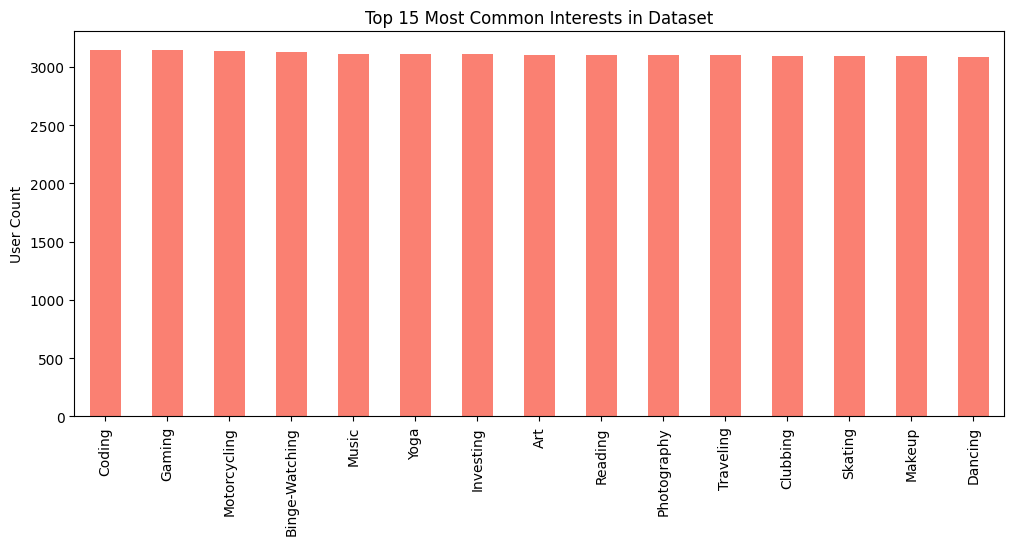

In [ ]:
# Visualize the most popular interests
plt.figure(figsize=(12,5))
y_df.sum().sort_values(ascending=False).head(15).plot(kind='bar', color='salmon')
plt.title('Top 15 Most Common Interests in Dataset')
plt.ylabel('User Count')
plt.show()

The heatmap indicates how swipe ratios correlate with actual matches. This ensures our features have enough "signal" to help the model make accurate predictions.

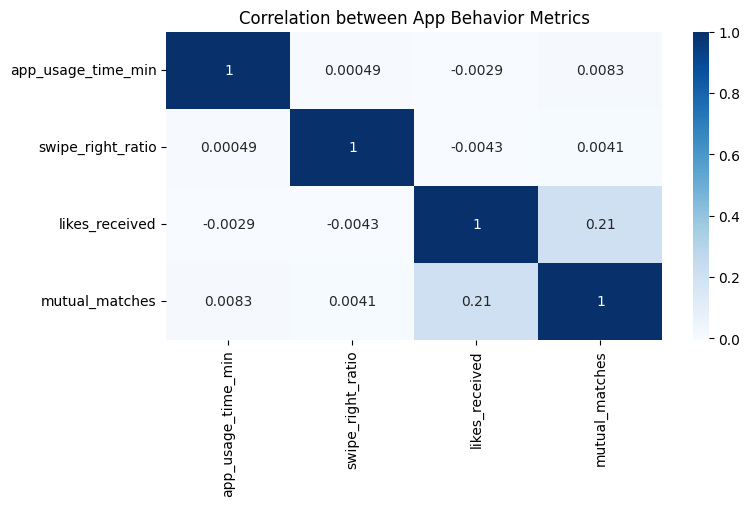

In [ ]:
# Check the correlation of our interaction behaviors
plt.figure(figsize=(8,4))
sns.heatmap(X[['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches']].corr(), annot=True, cmap='Blues')
plt.title('Correlation between App Behavior Metrics')
plt.show()

To visualize the distribution of key numerical features using box plots

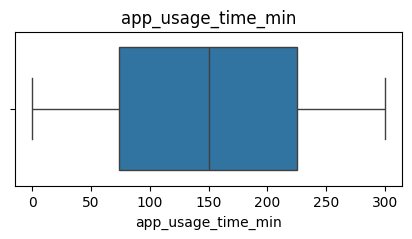

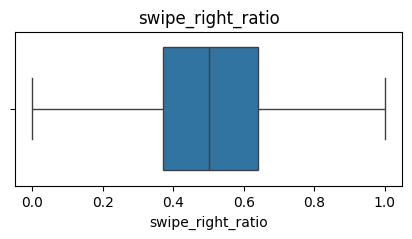

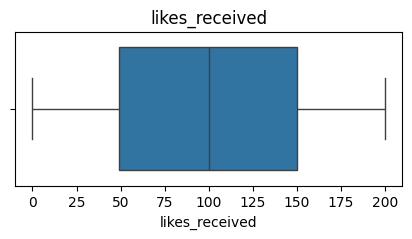

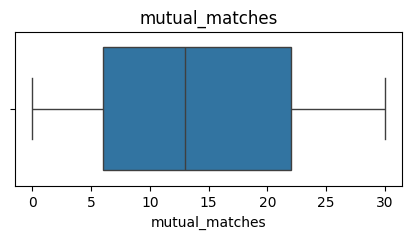

In [ ]:
numerical_cols = ['app_usage_time_min', 'swipe_right_ratio',
                  'likes_received', 'mutual_matches']

for col in numerical_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()



---

# Data Validation

Machine Learning Models # New Section

In [ ]:
import pandas as pd

# Convert back to DataFrame to save
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

# Save and export new files
X_train_final.to_csv('X_train_scaled_fixed.csv', index=False)
X_test_final.to_csv('X_test_scaled_fixed.csv', index=False)

NameError: name 'pd' is not defined

In [ ]:
# Ensure the features are numeric and targets are ready
print("Features (X) Shape:", X_train_final.shape)
print("Target (y) Shape:", y_train.shape)
print("\nFirst 5 rows of processed features:")
X_train_final.head()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Load files ─────────────────────────
X_train_final = pd.read_csv('X_train_scaled_fixed.csv')
X_test_final  = pd.read_csv('X_test_scaled_fixed.csv')

# ── Get interest_group target from original dataset ───────
df = pd.read_csv('dating_app_behavior_dataset.csv')

interest_groups = {
    'Active & Outdoors': ['Fitness', 'Hiking', 'Running', 'Skating', 'MMA', 'Dancing', 'Yoga'],
    'Creative':          ['Art', 'Painting', 'Photography', 'Writing', 'Poetry', 'Crafting', 'DIY'],
    'Entertainment':     ['Clubbing', 'Movies', 'Music', 'Memes', 'Gaming', 'Anime', 'K-pop', 'Binge-Watching', 'Stand-up Comedy'],
    'Intellectual':      ['Coding', 'Tech', 'History', 'Politics', 'Reading', 'Podcasts', 'Languages', 'Investing', 'Startups'],
    'Lifestyle':         ['Cooking', 'Foodie', 'Fashion', 'Makeup', 'Pets', 'Parenting', 'Traveling', 'Tattoos', 'Sneaker Culture'],
    'Mindful':           ['Meditation', 'Spirituality', 'Astrology', 'Gardening', 'Board Games', 'Motorcycling', 'Cars']
}

interest_to_group = {}
for group, interests in interest_groups.items():
    for interest in interests:
        interest_to_group[interest] = group

df['primary_interest'] = df['interest_tags'].str.split(',').str[0].str.strip()
df['interest_group']   = df['primary_interest'].map(interest_to_group)

# ── Recreate exact same split to match teammate's indices ─
_, _, y_train, y_test = train_test_split(
    df.drop(columns=['interest_group']),
    df['interest_group'],
    test_size=0.2, random_state=42  # must match teammate's split
)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# ── Verify ────────────────────────────────────────────────
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train.shape)
print("Unmapped:", df[df['interest_group'].isna()]['primary_interest'].unique())
print("Class distribution:\n", y_train.value_counts())

FileNotFoundError: [Errno 2] No such file or directory: 'X_train_scaled_fixed.csv'

In [ ]:
# ── Check how many are unmapped ───────────────────────────
print("NaN count:", y_train.isna().sum())

# ── Drop NaN rows from both X and y ──────────────────────
nan_mask = y_train.notna()
X_train_final = X_train_final[nan_mask].reset_index(drop=True)
y_train = y_train[nan_mask].reset_index(drop=True)

nan_mask_test = y_test.notna()
X_test_final = X_test_final[nan_mask_test].reset_index(drop=True)
y_test = y_test[nan_mask_test].reset_index(drop=True)

# ── Verify ────────────────────────────────────────────────
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train.shape)
print("Classes:", y_train.unique())
print("Class distribution:\n", y_train.value_counts())

In [ ]:
# ── Decision Tree ─────────────────────────────────────────
dt_params = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train_final, y_train)
print("Best DT params:", dt_grid.best_params_)
print("DT CV Accuracy:", round(dt_grid.best_score_, 4))
print("DT Test Accuracy:", round(accuracy_score(y_test, dt_grid.predict(X_test_final)), 4))

# ── KNN ───────────────────────────────────────────────────
knn_params = {
    'n_neighbors': [3, 5, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
knn_grid.fit(X_train_final, y_train)
print("Best KNN params:", knn_grid.best_params_)
print("KNN CV Accuracy:", round(knn_grid.best_score_, 4))
print("KNN Test Accuracy:", round(accuracy_score(y_test, knn_grid.predict(X_test_final)), 4))

# ── Logistic Regression ───────────────────────────────────
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['saga'],
    'max_iter': [2000]
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_final, y_train)
print("Best LR params:", lr_grid.best_params_)
print("LR CV Accuracy:", round(lr_grid.best_score_, 4))
print("LR Test Accuracy:", round(accuracy_score(y_test, lr_grid.predict(X_test_final)), 4))

# ── Final Evaluation ──────────────────────────────────────
models = {
    "Decision Tree":       dt_grid.best_estimator_,
    "KNN":                 knn_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test_final)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
    print(classification_report(y_test, y_pred))


---

# **Machine Learning Models**





## Decision Tree Models ##

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Feature Selection
X = df[['app_usage_time_min',
        'swipe_right_ratio',
        'income_bracket',
        'education_level',
        'likes_received',
        'mutual_matches']]

y = df['interest_tags']

# Encode categorical columns
le_income = LabelEncoder()
le_education = LabelEncoder()
le_target = LabelEncoder()

X['income_bracket'] = le_income.fit_transform(X['income_bracket'])
X['education_level'] = le_education.fit_transform(X['education_level'])

y = le_target.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", accuracy)

/tmp/ipykernel_1756/2824943268.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['income_bracket'] = le_income.fit_transform(X['income_bracket'])
/tmp/ipykernel_1756/2824943268.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['education_level'] = le_education.fit_transform(X['education_level'])


Decision Tree Accuracy: 0.0


In [13]:
print(df.head())

              gender sexual_orientation location_type income_bracket  \
0  Prefer Not to Say                Gay         Urban           High   
1               Male           Bisexual      Suburban   Upper-Middle   
2         Non-binary          Pansexual      Suburban            Low   
3        Genderfluid                Gay         Metro       Very Low   
4               Male           Bisexual         Urban         Middle   

       education_level                  interest_tags  app_usage_time_min  \
0           Bachelor’s   Fitness, Politics, Traveling                  52   
1  No Formal Education  Languages, Fashion, Parenting                 279   
2             Master’s           Movies, Reading, DIY                  49   
3              Postdoc      Coding, Podcasts, History                 185   
4           Bachelor’s       Clubbing, Podcasts, Cars                  83   

  app_usage_time_label  swipe_right_ratio swipe_right_label  likes_received  \
0             Moderate   